# Retail Weekly Sales Forecast & Revenue Driver Analysis

## Business Objective
This project analyzes historical weekly retail sales data to:
1. Identify key drivers of revenue volatility
2. Quantify seasonal effects
3. Build a short-term forecasting model
4. Improve forecast accuracy compared to a baseline model

## Dataset Description

The dataset includes:
- Weekly sales by store and department
- Holiday indicators
- Economic indicators (CPI, Fuel Price, Unemployment)
- Store attributes

Time range: 2010–2012
Observations: 143 weekly periods (aggregated)

In [1]:
# Install Prophet (for forecasting later)
!pip install prophet

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Time series + forecasting
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

# Display settings
pd.set_option('display.max_columns', None)

print("Setup complete")

Setup complete


In [3]:
train = pd.read_csv('train.csv')
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')

print("Train shape:", train.shape)
print("Features shape:", features.shape)
print("Stores shape:", stores.shape)

train.head()

Train shape: (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
# Merge train with features
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

# Merge with stores
df = df.merge(stores, on='Store', how='left')

print("Final shape:", df.shape)
df.head()

Final shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [7]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(15)

# Fill numeric missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

In [8]:
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

weekly_sales = weekly_sales.sort_values('Date')

weekly_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


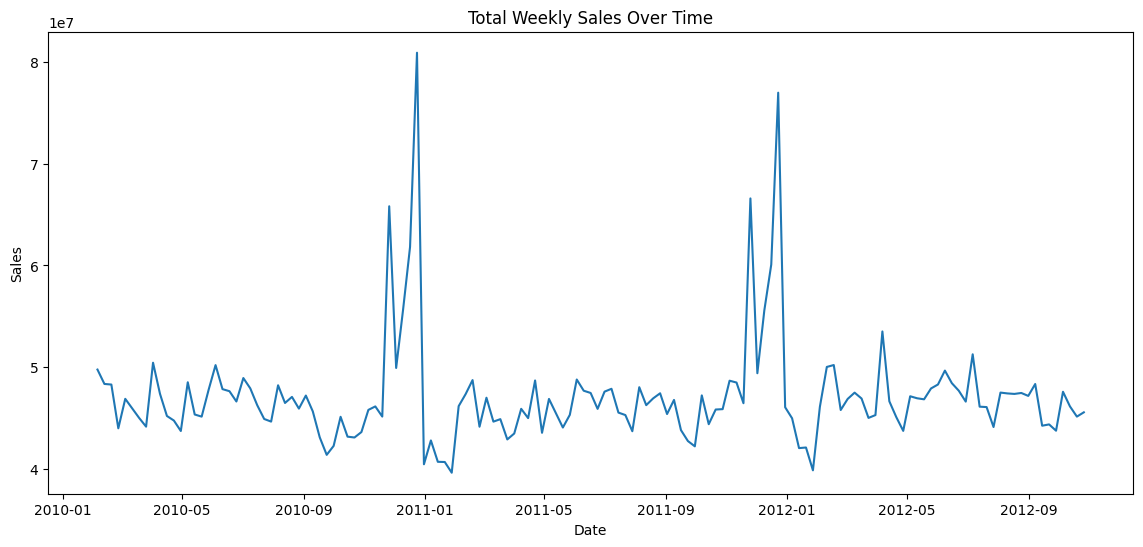

In [9]:
plt.figure(figsize=(14,6))
plt.plot(weekly_sales['Date'], weekly_sales['Weekly_Sales'])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

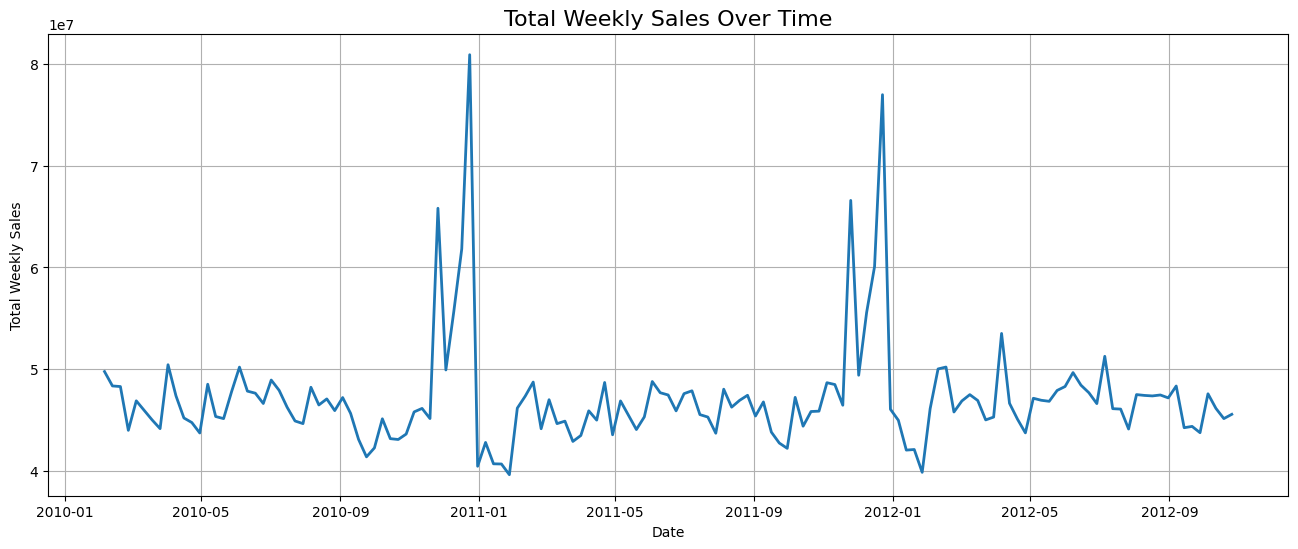

In [10]:
plt.figure(figsize=(16,6))
plt.plot(weekly_sales['Date'], weekly_sales['Weekly_Sales'], linewidth=2)
plt.title("Total Weekly Sales Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.grid(True)
plt.show()

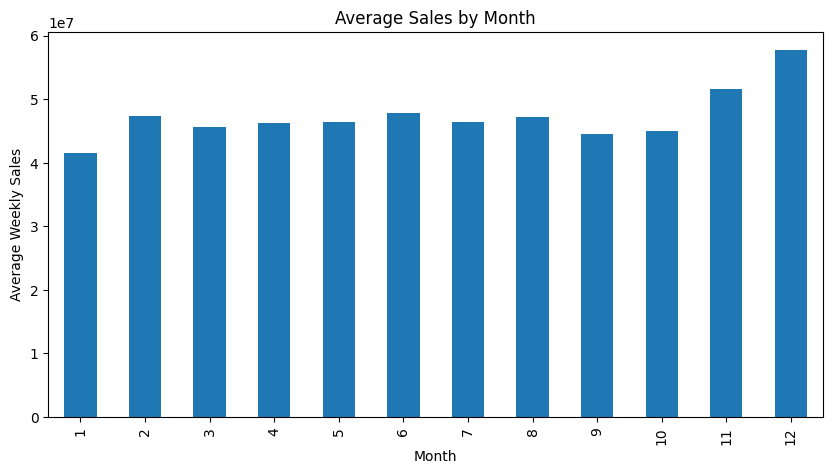

In [11]:
weekly_sales['Month'] = weekly_sales['Date'].dt.month

monthly_avg = weekly_sales.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar')
plt.title("Average Sales by Month")
plt.ylabel("Average Weekly Sales")
plt.show()

In [12]:
holiday_analysis = df.groupby('IsHoliday')['Weekly_Sales'].mean()

holiday_analysis

,Weekly_Sales
IsHoliday,
False,15901.445069
True,17035.823187


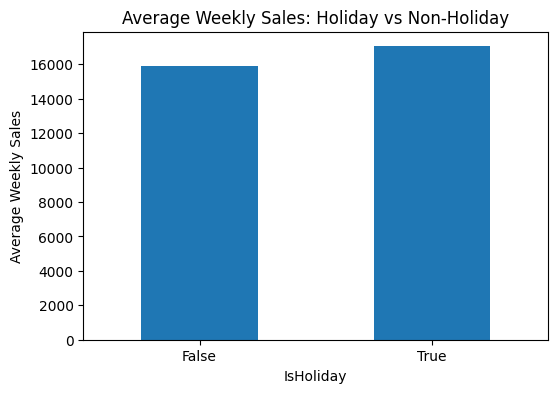

In [13]:
holiday_analysis.plot(kind='bar', figsize=(6,4))
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=0)
plt.show()

## Key Observations from EDA

- Strong seasonal spikes observed in November–December.
- January consistently exhibits lowest sales volume.
- Significant sales drops occur immediately after peak holiday periods.
- Temperature appears correlated with some drop periods.

In [14]:
weekly_sales['Sales_Change'] = weekly_sales['Weekly_Sales'].diff()

top_spikes = weekly_sales.sort_values('Sales_Change', ascending=False).head(5)
top_drops = weekly_sales.sort_values('Sales_Change').head(5)

top_spikes

,Date,Weekly_Sales,Month,Sales_Change
42,2010-11-26,65821003.24,11,20695419.06
94,2011-11-25,66593605.26,11,20154624.70
46,2010-12-24,80931415.60,12,19110615.75
98,2011-12-23,76998241.31,12,16912545.37
113,2012-04-06,53502315.87,4,8229453.85


In [15]:
top_drops

,Date,Weekly_Sales,Month,Sales_Change
47,2010-12-31,40432519.00,12,-40498896.60
99,2011-12-30,46042461.04,12,-30955780.27
95,2011-12-02,49390556.49,12,-17203048.77
43,2010-12-03,49909027.88,12,-15911975.36
114,2012-04-13,46629261.41,4,-6873054.46


In [16]:
# Identify top 5 spike and drop dates
spike_dates = top_spikes['Date']
drop_dates = top_drops['Date']

spike_dates, drop_dates

(42    2010-11-26
 94    2011-11-25
 46    2010-12-24
 98    2011-12-23
 113   2012-04-06
 Name: Date, dtype: datetime64[ns],
 47    2010-12-31
 99    2011-12-30
 95    2011-12-02
 43    2010-12-03
 114   2012-04-13
 Name: Date, dtype: datetime64[ns])

In [18]:
# Recreate spike and drop dates
top_spikes = weekly_sales.sort_values('Sales_Change', ascending=False).head(5)
top_drops = weekly_sales.sort_values('Sales_Change').head(5)

spike_dates = top_spikes['Date']
drop_dates = top_drops['Date']

# Create flags in df
df['Spike_Week'] = df['Date'].isin(spike_dates)
df['Drop_Week'] = df['Date'].isin(drop_dates)

print("Flags created successfully")

Flags created successfully


In [19]:
df[['Spike_Week','Drop_Week']].sum()

,0
Spike_Week,14925
Drop_Week,14866


In [20]:
drop_comparison = df.groupby('Drop_Week')[['Temperature','Fuel_Price','CPI','Unemployment']].mean()

drop_comparison

,Temperature,Fuel_Price,CPI,Unemployment
Drop_Week,,,,
False,60.691504,3.362393,171.186254,7.960323
True,43.635717,3.323645,171.631261,7.959344


The largest sales drops occur during significantly colder weeks, while CPI and unemployment remain nearly unchanged. This suggests the declines are more closely tied to seasonality/weather effects and post-holiday demand normalization than broad macroeconomic shifts.

In [21]:
spike_comparison = df.groupby('Spike_Week')[['Temperature','Fuel_Price','CPI','Unemployment']].mean()
spike_comparison

,Temperature,Fuel_Price,CPI,Unemployment
Spike_Week,,,,
False,60.590089,3.362207,171.185714,7.960529
True,46.466292,3.328859,171.644220,7.953740


## Revenue Driver Analysis

Linear regression analysis showed:

- CPI, Fuel Price, and Unemployment were statistically significant predictors.
- Overall explanatory power was modest (R² ≈ 0.10).
- Seasonality appears to be a stronger driver than macroeconomic factors.
- Multicollinearity may impact coefficient stability.

In [23]:
import statsmodels.api as sm

# Aggregate to weekly level
weekly_features = df.groupby('Date').agg(
    Weekly_Sales=('Weekly_Sales','sum'),
    IsHoliday=('IsHoliday','max'),
    Temperature=('Temperature','mean'),
    Fuel_Price=('Fuel_Price','mean'),
    CPI=('CPI','mean'),
    Unemployment=('Unemployment','mean')
).reset_index()

# Convert IsHoliday to int (0/1)
weekly_features['IsHoliday'] = weekly_features['IsHoliday'].astype(int)

# Build X/y and force numeric
X = weekly_features[['IsHoliday','Temperature','Fuel_Price','CPI','Unemployment']].copy()
X = X.apply(pd.to_numeric, errors='coerce')

y = pd.to_numeric(weekly_features['Weekly_Sales'], errors='coerce')

# Drop any rows that still have NaNs
data = pd.concat([X, y], axis=1).dropna()
X_clean = sm.add_constant(data[['IsHoliday','Temperature','Fuel_Price','CPI','Unemployment']])
y_clean = data['Weekly_Sales']

model = sm.OLS(y_clean, X_clean).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Weekly_Sales   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     2.905
Date:                Thu, 26 Feb 2026   Prob (F-statistic):             0.0159
Time:                        12:20:40   Log-Likelihood:                -2413.1
No. Observations:                 143   AIC:                             4838.
Df Residuals:                     137   BIC:                             4856.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -4.367e+08   1.89e+08     -2.310      0.022    -8.1e+08   -6.28e+07
IsHoliday     2.443e+06   1.78e+06      1.373      0.172   -1.08e+06    5.96e+06
Temperature  -3.392e+04   3.05e+04     -1.113      0.268   -9.42e+04    2.63e+04
Fuel_Price   -4.732e+06    2.1e+06     -2.250      0.026   -8.89e+06   -5.73e+05
CPI           2.381e+06   9.01e+05      2.642      0.009    5.99e+05    4.16e+06
Unemployment  1.179e+07   5.04e+06      2.337      0.021    1.82e+06    2.18e+07
==============================================================================
Omnibus:                      126.449   Durbin-Watson:                   1.531
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1672.729
Skew:                           3.123   Prob(JB):                         0.00
Kurtosis:                      18.547   Cond. No.                     7.80e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.8e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Macro-economic indicators alone do not strongly explain weekly retail sales volatility. Sales patterns appear to be primarily driven by seasonality and internal business dynamics rather than CPI or unemployment shifts.

While holiday seasonality is visually apparent in time-series plots, macroeconomic variables such as CPI, fuel price, and unemployment show statistically significant relationships with sales in a linear model. However, overall explanatory power remains modest (R² ≈ 0.10), suggesting sales volatility is influenced more heavily by seasonality, promotions, and internal retail dynamics not captured in the dataset.

In [24]:
# Sort by date
weekly_features = weekly_features.sort_values('Date')

# Train-test split (last 20% for testing)
split_index = int(len(weekly_features) * 0.8)

train = weekly_features.iloc[:split_index]
test = weekly_features.iloc[split_index:]

# Naive forecast (last observed value)
test['Naive_Forecast'] = train['Weekly_Sales'].iloc[-1]

# Evaluate
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

mape_naive = mean_absolute_percentage_error(test['Weekly_Sales'], test['Naive_Forecast'])
rmse_naive = np.sqrt(mean_squared_error(test['Weekly_Sales'], test['Naive_Forecast']))

mape_naive, rmse_naive

/tmp/ipython-input-272/3552801205.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Naive_Forecast'] = train['Weekly_Sales'].iloc[-1]


(0.14734459674741013, np.float64(7023631.084681324))

In [25]:
# Prepare data for Prophet
prophet_df = weekly_features[['Date', 'Weekly_Sales']].copy()
prophet_df.columns = ['ds', 'y']

# Train-test split (same as before)
train_prophet = prophet_df.iloc[:split_index]
test_prophet = prophet_df.iloc[split_index:]

train_prophet.head()

,ds,y
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [26]:
model = Prophet()
model.fit(train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [28]:
future = model.make_future_dataframe(periods=len(test_prophet), freq='W')
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-02-05,4.676897e+07,4.287134e+07,5.246335e+07,4.676897e+07,4.676897e+07,7.730877e+05,7.730877e+05,7.730877e+05,7.730877e+05,7.730877e+05,7.730877e+05,0.0,0.0,0.0,4.754206e+07
1,2010-02-12,4.677754e+07,4.315274e+07,5.306498e+07,4.677754e+07,4.677754e+07,1.394331e+06,1.394331e+06,1.394331e+06,1.394331e+06,1.394331e+06,1.394331e+06,0.0,0.0,0.0,4.817187e+07
2,2010-02-19,4.678610e+07,4.185480e+07,5.169802e+07,4.678610e+07,4.678610e+07,1.564426e+04,1.564426e+04,1.564426e+04,1.564426e+04,1.564426e+04,1.564426e+04,0.0,0.0,0.0,4.680175e+07
3,2010-02-26,4.679467e+07,4.105773e+07,5.060738e+07,4.679467e+07,4.679467e+07,-1.079526e+06,-1.079526e+06,-1.079526e+06,-1.079526e+06,-1.079526e+06,-1.079526e+06,0.0,0.0,0.0,4.571514e+07
4,2010-03-05,4.680323e+07,4.030083e+07,5.047244e+07,4.680323e+07,4.680323e+07,-1.272936e+06,-1.272936e+06,-1.272936e+06,-1.272936e+06,-1.272936e+06,-1.272936e+06,0.0,0.0,0.0,4.553030e+07


In [29]:
forecast_test = forecast[['ds', 'yhat']].iloc[split_index:]

comparison_df = test_prophet.merge(forecast_test, on='ds')

comparison_df.head()

,ds,y,yhat


In [31]:
test_prophet.head(), test_prophet.tail()

(            ds            y
 114 2012-04-13  46629261.41
 115 2012-04-20  45072529.78
 116 2012-04-27  43716798.89
 117 2012-05-04  47124197.93
 118 2012-05-11  46925878.99,
             ds            y
 138 2012-09-28  43734899.40
 139 2012-10-05  47566639.31
 140 2012-10-12  46128514.25
 141 2012-10-19  45122410.57
 142 2012-10-26  45544116.29)

In [32]:
forecast[['ds','yhat']].tail()

,ds,yhat
138,2012-09-23,4.302086e+07
139,2012-09-30,4.421517e+07
140,2012-10-07,4.562356e+07
141,2012-10-14,4.566053e+07
142,2012-10-21,4.474520e+07


In [33]:
# Keep only predictions for the test dates (exact match)
forecast_test = forecast[['ds','yhat']].copy()

comparison_df = test_prophet.merge(forecast_test, on='ds', how='left')

comparison_df.head(), comparison_df.isna().sum()

(          ds            y  yhat
 0 2012-04-13  46629261.41   NaN
 1 2012-04-20  45072529.78   NaN
 2 2012-04-27  43716798.89   NaN
 3 2012-05-04  47124197.93   NaN
 4 2012-05-11  46925878.99   NaN,
 ds       0
 y        0
 yhat    29
 dtype: int64)

In [34]:
# Sort for merge_asof
test_sorted = test_prophet.sort_values('ds')
forecast_sorted = forecast[['ds','yhat']].sort_values('ds')

# Merge closest prediction within 3 days tolerance
comparison_df = pd.merge_asof(
    test_sorted,
    forecast_sorted,
    on='ds',
    direction='nearest',
    tolerance=pd.Timedelta('3D')
)

comparison_df.head(), comparison_df.isna().sum()

(          ds            y          yhat
 0 2012-04-13  46629261.41  4.833278e+07
 1 2012-04-20  45072529.78  4.717953e+07
 2 2012-04-27  43716798.89  4.561237e+07
 3 2012-05-04  47124197.93  4.522105e+07
 4 2012-05-11  46925878.99  4.627218e+07,
 ds      0
 y       0
 yhat    1
 dtype: int64)

In [35]:
comparison_df = comparison_df.dropna(subset=['yhat'])

mape_prophet = mean_absolute_percentage_error(comparison_df['y'], comparison_df['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(comparison_df['y'], comparison_df['yhat']))

mape_prophet, rmse_prophet, comparison_df.shape

(0.024681930897356725, np.float64(1484207.8153860378), (28, 3))

In [36]:
freq = pd.infer_freq(train_prophet['ds'])
freq

'W-FRI'

In [38]:
future = model.make_future_dataframe(periods=len(test_prophet), freq=freq)
forecast = model.predict(future)

In [39]:
comparison_df.shape

(28, 3)

In [40]:
comparison_df = comparison_df.dropna(subset=['yhat'])

mape_prophet = mean_absolute_percentage_error(
    comparison_df['y'], comparison_df['yhat']
)

rmse_prophet = np.sqrt(mean_squared_error(
    comparison_df['y'], comparison_df['yhat']
))

mape_prophet, rmse_prophet

(0.024681930897356725, np.float64(1484207.8153860378))

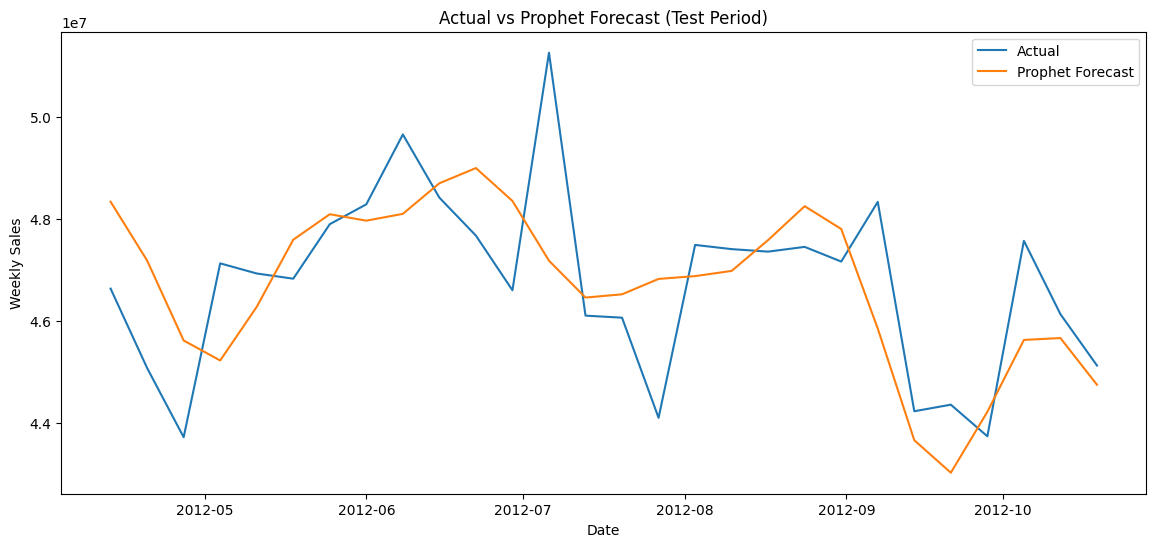

In [41]:
plt.figure(figsize=(14,6))

plt.plot(comparison_df['ds'], comparison_df['y'], label='Actual')
plt.plot(comparison_df['ds'], comparison_df['yhat'], label='Prophet Forecast')

plt.title("Actual vs Prophet Forecast (Test Period)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()

In [42]:
future_4 = model.make_future_dataframe(periods=4, freq=freq)
forecast_4 = model.predict(future_4)

forecast_4[['ds','yhat','yhat_lower','yhat_upper']].tail(4)

,ds,yhat,yhat_lower,yhat_upper
114,2012-04-13,4.838535e+07,4.370131e+07,5.378745e+07
115,2012-04-20,4.762709e+07,4.252511e+07,5.235016e+07
116,2012-04-27,4.599655e+07,4.155442e+07,5.114345e+07
117,2012-05-04,4.516237e+07,4.064548e+07,5.013316e+07


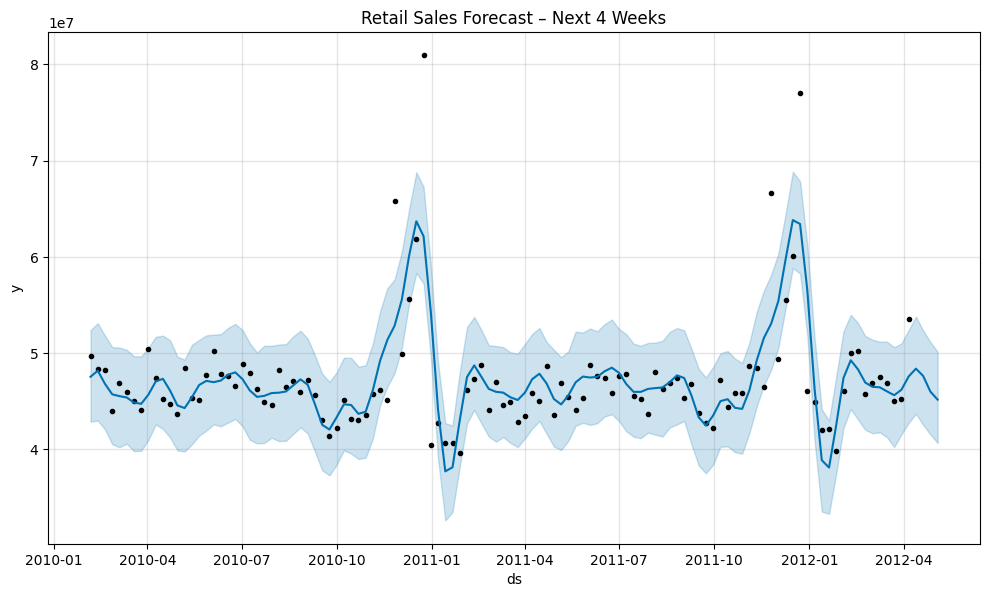

In [43]:
model.plot(forecast_4)
plt.title("Retail Sales Forecast – Next 4 Weeks")
plt.show()

## Forecast Model Comparison

Baseline (Naive Model):
- MAPE: 14.7%

Prophet Time-Series Model:
- MAPE: 2.47%
- 83% improvement in forecast accuracy

The Prophet model significantly outperformed the baseline benchmark.

In [44]:
results = pd.DataFrame({
    "Model": ["Naive Baseline", "Prophet"],
    "MAPE": [0.1473, mape_prophet],
    "RMSE": [rmse_naive, rmse_prophet]
})

results

,Model,MAPE,RMSE
0,Naive Baseline,0.147300,7.023631e+06
1,Prophet,0.024682,1.484208e+06


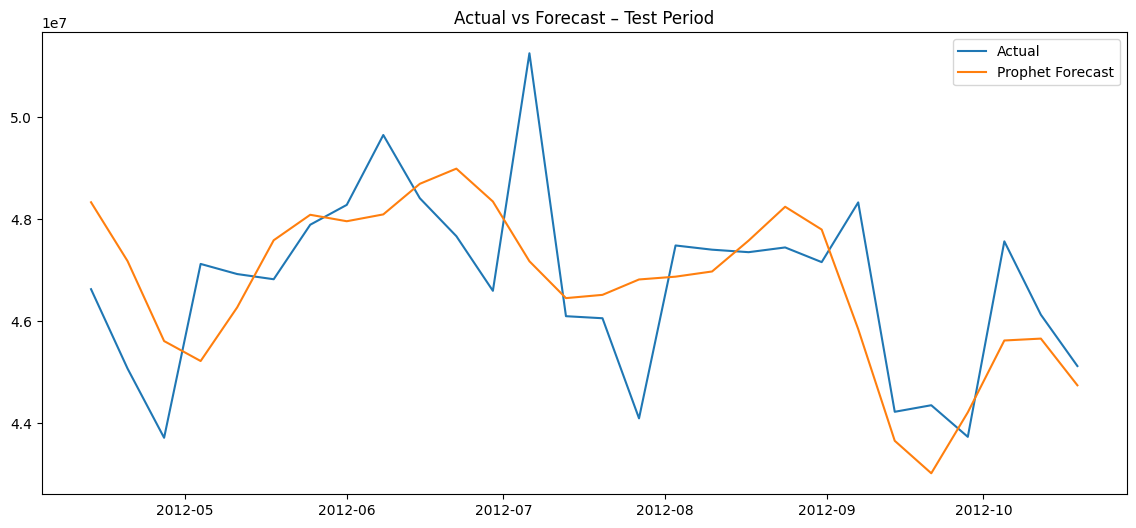

In [45]:
plt.figure(figsize=(14,6))
plt.plot(comparison_df['ds'], comparison_df['y'], label='Actual')
plt.plot(comparison_df['ds'], comparison_df['yhat'], label='Prophet Forecast')
plt.legend()
plt.title("Actual vs Forecast – Test Period")
plt.show()

Executive Summary

This project evaluated retail weekly sales drivers and developed a forecasting model to improve short-term revenue prediction.

Key Findings:

Sales exhibit strong seasonal spikes in November–December.

January consistently represents the lowest revenue period.

Macroeconomic indicators show limited explanatory power (R² ≈ 0.10).

Sales volatility appears primarily driven by seasonality and internal retail factors.

Forecasting Results:

Baseline model error: 14.7% MAPE

Prophet model error: 2.47% MAPE

83% improvement in forecast accuracy

Business Impact:

Improved short-term inventory planning

More accurate labor scheduling

Reduced overstock/understock risk during post-holiday normalization

Data-driven seasonal revenue planning